# Stock

In [1]:
import os
import textwrap
import math
import pandas as pd
import numpy as np

from datetime import datetime
from dateutil.relativedelta import relativedelta

import google.generativeai as genai
from langchain.schema.messages import AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from google.generativeai.types import HarmBlockThreshold
from google.ai.generativelanguage_v1 import HarmCategory

from IPython.display import display
from IPython.display import Markdown

model = 'gemini-1.5-flash'
temperature = 1
top_p = 0.9
seed = 0

def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

llm = ChatGoogleGenerativeAI(
                google_api_key = os.getenv('GEMINI_API_KEY'),
                model=model,
                temperature=temperature,
                top_p=top_p,
                seed=seed,
                safety_settings={
                        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT : HarmBlockThreshold.BLOCK_NONE,
                
            })

# 定義策略元素字典，每個元素對應一個代號
elements = {
    "E1": "企業創新策略：企業創新的核心主題，涵蓋所有驅動企業增長和競爭力提升的策略。",
    "E2": "滿足客戶需求：企業創新的首要驅動力，能否滿足客戶需求直接影響創新成敗。",
    "E3": "吸引投資者關注：投資者的關注和信心能為企業提供必要的資金和支持，是創新成功的重要標誌。",
    "E4": "市場需求與趨勢：市場需求的變化和行業趨勢是影響企業股票表現的關鍵因素，企業需適應並預測市場變化。",
    "E5": "財務表現：穩定且增長的收入、利潤和現金流是吸引投資者的主要因素，能增加投資者信心，推動股價上漲。",
    "E6": "技術進步與研發投入：持續的技術創新和研發投入能提高企業競爭力和市場地位，促進企業長期增長。",
    "E7": "經營效率：有效的經營管理能提高企業盈利能力，進而提升股票價值。",
    "E8": "品牌聲譽與市場認可度：良好的品牌聲譽和市場認可度能增加企業產品的市場需求，促進銷售增長。",
    "E9": "政策與法規支持：政府政策和法規對行業的支持或限制會直接影響企業的發展前景和市場表現。",
    "E10": "競爭優勢與市場份額：企業在市場中的競爭優勢和市場份額的提升能增強其市場地位，吸引更多投資者。",
    "E11": "全球化與國際市場拓展：進入國際市場並擴展全球業務能增加企業的市場規模和收入來源。",
    "E12": "風險管理與應對能力：有效的風險管理策略和應對能力能降低企業運營風險，提高投資者信心。",
    "E13": "人才管理與員工激勵：擁有高素質的人才和有效的激勵機制能提升企業創新能力和生產效率。",
    "E14": "合作夥伴關係：與其他企業建立戰略合作夥伴關係能共享資源和技術，提升市場競爭力。",
    "E15": "市場營銷與品牌推廣：有效的市場營銷和品牌推廣策略能提高企業知名度和市場需求。",
    "E16": "客戶服務與滿意度：高品質的客戶服務和較高的客戶滿意度能提高客戶忠誠度和口碑。",
    "E17": "供應鏈管理：高效的供應鏈管理能確保產品質量和交付效率，降低成本。",
    "E18": "產品多樣化與創新：不斷推出創新產品和服務能滿足不同市場需求，提升企業競爭力。",
    "E19": "環保與可持續發展：採用環保和可持續發展策略能提高企業形象，吸引關注可持續投資的投資者。",
    "E20": "數位轉型與科技應用：積極進行數位轉型和應用新技術能提高運營效率和市場響應速度。",
    "E21": "競爭對手分析與市場擴展：深入分析競爭對手的策略和行動，制定有效的市場擴展和新市場進入策略。",
    "E22": "資本結構、財務穩定性與資金籌措：健康的資本結構和財務穩定性以及有效的資金籌措能增強企業的抗風險能力和持續發展能力。",
    "E23": "客戶數據分析：利用大數據和數據分析技術深入了解客戶需求，提升產品和服務的針對性。",
    "E24": "知識產權保護：有效保護企業的知識產權能防止競爭對手抄襲，提高創新成果的市場價值。",
    "E25": "企業文化與價值觀：建立積極向上的企業文化和價值觀能吸引優秀人才，提升企業凝聚力和創新力。",
    "E26": "股東回報與分紅政策：穩定的股東回報和合理的分紅政策能吸引長期投資者。",
    "E27": "社會責任與公益活動：積極參與社會責任和公益活動能提升企業形象，獲得更多社會支持。",
    "E28": "成本控制: 有效的成本控制能提高企業獲利能力。",
}

    # ["2330", "台積電"],
    # ["2317", "鴻海"],
    # ["2454", "聯發科"],
    # ["2382", "廣達"],
    # ["2881", "富邦金"],
    # ["2308", "台達電"],
    # ["2412", "中華電"],
    # ["2882", "國泰金"],
    # ["2891", "中信金"],
    # ["3711", "日月光"],
    # ["6505", "台塑化"],
    # ["2357", "華碩"],
    # ["1216", "統一"],
    # ["3045", "台灣大"],
    # ["2603", "長榮"],
    # ["2303", "聯電"],
    # ["2886", "兆豐金"],
    # ["2884", "玉山金"],
    # ["2885", "元大金"],
    # ["5880", "合庫金"],
    # ["2892", "第一金"],
    # ["2207", "和泰車"],
    # ["2880", "華南金"],

stock_ids = ['2330', '2317', '2454', '2382', '2881', '2308', '2412', '2882', '2891', '3711', '6505', '2357', '1216', '3045', '2603', '2303', '2886', '2884', '2885', '5880', '2892', '2207', '2880']
stock_names = ['台積電', '鴻海', '聯發科', '廣達', '富邦金', '台達電', '中華電', '國泰金', '中信金', '日月光', '台塑化', '華碩', '統一', '台灣大', '長榮', '聯電', '兆豐金', '玉山金', '元大金', '合庫金', '第一金', '和泰車', '華南金']

stock_ids = stock_ids[:10]

# stock_ids = ['2330', '2454', '2317', '2382', '2308', '3711']
# stock_names = ['台積電', '聯發科', '鴻海', '廣達', '台達電', '日月光']

# stock_ids = ['2881', '2412', '2882', '2891', '6505', '2357', '1216', '3045', '2603', '2303', '2886', '2884', '2885', '5880', '2892', '2207', '2880']
# stock_names = ['富邦金', '中華電', '國泰金', '中信金', '台塑化', '華碩', '統一', '台灣大', '長榮', '聯電', '兆豐金', '玉山金', '元大金', '合庫金', '第一金', '和泰車', '華南金']

global stock_id
global stock_name 
stock_id = ''
stock_name = ''
# path_price = ''
# path_news_title = ''
path_out = "out_stock/compare_reverse_ynu/"



/Users/yanyifu/Documents/_Coding/LLM Predict Stock/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 使用過的 Prompt

p1

In [2]:
# {stock_name}的{prompt_tech}
# 以下是新聞標題：『{prompt_news}』
# 請一步一步的用上面的資訊思考{stock_name}隔天開盤到收盤的可能漲跌，如果你認為{stock_name}會上漲請回答#yes，如果你認為{stock_name}會下跌請回答#no

# 用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
# 判斷結果: #yes/#no
# 你的理由: 說明你的判斷理由

p2

In [3]:
# {stock_name}的{prompt_tech}
# 以下是新聞標題：『{prompt_news}』
# 請一步一步的用上面的資訊思考{stock_name}隔天開盤買進到收盤賣出的獲利可能性，如果你認為會獲利請回答#yes，如果你認為會虧損請回答#no

# 用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
# 判斷結果: #yes/#no
# 你的理由: 說明你的判斷理由

# 主程式

In [4]:
# 透過前一天的新聞判斷今日的股市走勢
import time
import os
import json
import pandas as pd
from datetime import datetime, timedelta

def call_tech(d, path_price):
    
    df = pd.read_csv(path_price, encoding='utf-8')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')
    df = df[(d == df['Date'])]

    # 計算5日均線
    ema5 = "上漲" if df["Close"].values[0] > df['EMA5'].values[0] else "下跌"
    
    elements_tech = [
        # f"五日均線為{ma5}趨勢",
        # f"收盤後股價在5日均線{ma5},10日均線{ma10},20日均線{ma20}",
        # f"RSI值為{round(df['RSI'].values[0], 3)}",
        # f"MACD指標值, DIF-MACD值:{dif_macd}",
        # f"KD值為,k:{round(df['K'].values[0],1)},d:{round(df['D'].values[0], 1)}",
        # f'開盤{df["開盤指數"].values[0]}，最高{df["最高指數"].values[0]}，最低{df["Low"].values[0]}，收盤{df["Close"].values[0]}',
        # f"收盤後股價在12日加權平均線{ema12},26日加權平均線{ema26}",
        f"五日加權移動平均線為{ema5}趨勢",
    ]

    prompt_tech = ""
    for i in range(len(elements_tech)):
        prompt_tech += f"{str(i+1)} : {elements_tech[i]}\n"
    return prompt_tech

def analyze_market(st, et, path_price, path_news_title):
    # 讀取CSV檔案
    df_price_his = pd.read_csv(path_price, encoding='utf-8')
    df_price_his['Date'] = pd.to_datetime(df_price_his['Date'], format='%Y%m%d')
    df_price_his = df_price_his[(st <= df_price_his['Date']) & (df_price_his['Date'] <= et)]

    idx = 1
    batch_size = 500
    output_data = {}  # 使用字典來存儲每一天的輸出數據

    while idx < len(df_price_his):
        batch = []
        for i in range(batch_size):
            if idx + i >= len(df_price_his):
                break
            
            # 取得前一日日期和新聞標題
            news_date = df_price_his.iloc[idx + i]['Date'] - timedelta(days=1)
            prompt_news = ""
            with open(path_news_title, 'r', encoding='utf-8') as f:
                news_data = json.load(f)
                prompt_news += f"{news_data[news_date.strftime('%Y%m%d')]} \n"
            
            # 取得前一個交易日的技術指標
            last_date = df_price_his.iloc[idx + i - 1]['Date']
            prompt_tech = call_tech(last_date, path_price)
            # 當日股價的技術指標如下： 『{tech_prompt}』
            # {stock_name}的{tech_prompt}

            # 建立prompt
            messages = [
                ("system", "你是一個厲害的股市操盤手，專長是當日沖消"),
                ("human",
f"""
{stock_name}的{prompt_tech}
以下是新聞標題：『{prompt_news}』
請一步一步的用上面的資訊思考{stock_name}隔天開盤買進到收盤賣出的獲利可能性，如果你認為會獲利請回答#yes，如果你認為會虧損請回答#no，如果無法判斷請回答#unknown

用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
判斷結果: #yes/#no/#unknown 請盡量不要回答unknown
你的理由: 說明你的判斷理由
""")
            ]
            batch.append(messages)

        res = llm.batch(batch)

        for i in range(len(res)):
            # 被預測的日期
            date_str = df_price_his.iloc[idx + i]['Date'].strftime('%Y%m%d')
            output_data[date_str] = {
                "token": res[i].usage_metadata,
                "raw_data": res[i].content,
            }

        # time.sleep(60)
        idx += batch_size

    # 將所有輸出數據寫入字典中
    data = {
        "model": model,
        "temperature": temperature,
        "top_p": top_p,
        "seed": seed,
        "output_data": output_data,
    }
    
    return data

In [5]:
def save_data(folder_path, data):
    # count = 1
    # while True:
    #     if os.path.exists(folder_path + str(count) + ".json"):
    #         count += 1
    #         continue
    #     else:
    #         out_file = folder_path + str(count) + ".json"
    #         break
    out_file = folder_path + ".json"
    json_content = json.dumps(data, ensure_ascii=False, indent=4)
    os.makedirs(os.path.dirname(out_file), exist_ok=True)
    with open(out_file, "w", encoding="UTF-8") as f:
        f.write(json_content)
    
    return out_file

## 評分

In [6]:
import pandas as pd
import json
import os

def eval(output_data, path_price):
    # 計算準確率和平均報酬率
    gain = []
    loss = []
    gain_precision = []
    loss_precision = []

    tp = 0
    fp = 0
    tn = 0
    fn = 0

    token_input = 0
    token_output = 0

    df_price_his = pd.read_csv(path_price, encoding='utf-8')
    df_price_his['Date'] = pd.to_datetime(df_price_his['Date'], format='%Y%m%d')

    for date_str, result in output_data.items():
        token_input += result["token"]["input_tokens"]
        token_output += result["token"]["output_tokens"]
        sig_str = result["raw_data"].split("你的理由")[0]
        sig = 0

        if "unknown" in sig_str:
            sig = 0
        elif "yes" in sig_str:
            sig = 1
        elif "no" in sig_str:
            sig = -1
        else:
            sig = 0

        df_price = df_price_his[df_price_his['Date'] == pd.to_datetime(date_str, format='%Y%m%d')]

        if df_price.empty:
            continue

        rtn = (df_price.iloc[0]['Close'] - df_price.iloc[0]['Open']) / df_price.iloc[0]['Open']

        if pd.isna(rtn):
            rtn = 0

        if sig > 0:
            if rtn > 0:
                tp += 1
                gain.append(rtn)
                gain_precision.append(rtn)
            else:
                fp += 1
                loss.append(rtn)
                loss_precision.append(rtn)
        elif sig == -1:
            if rtn < 0:
                tn += 1
                gain.append(-rtn)
            else:
                fn += 1
                loss.append(-rtn)

    accuracy = 0
    precision = 0
    recall = 0
    ev = 0
    if tp + fp + tn + fn == 0 or tp + fp == 0 or tp + fn == 0:
        accuracy = 0
        precision = 0
        recall = 0
        ev = 0
        precision_ev = 0
    elif len(gain) == 0 or len(loss) == 0:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = 0
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    else:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = (sum(gain) / len(gain))*accuracy + (sum(loss) / len(loss))*(1-accuracy)
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    result = {
        'tp' : tp,
        'fp' : fp,
        'tn' : tn,
        'fn' : fn,
        'avail_count' : tp + fp + tn + fn,
        'ask_count': len(output_data),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'ev': ev,
        'precision_ev' : precision_ev,
        'token_input': token_input,
        'token_output': token_output,
    }

    return result

# RUN

In [25]:
start_day = datetime(2023, 1, 1)
end_day = datetime(2024, 6, 30)

prompt = ""

for i in range(len(stock_ids)):
    stock_id = stock_ids[i]
    stock_name = stock_names[i]

    print(f"stock_id: {stock_id}, stock_name: {stock_name}")
    path_price = os.path.join(os.path.abspath(os.path.dirname(os.getcwd())), 'history_data', 'tw', 'stock_price', stock_id + 'tech.csv')
    path_news_title = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + stock_id + "news_title.json"

    dic_data = analyze_market(start_day, end_day, path_price, path_news_title)
    result = eval(dic_data["output_data"], path_price)
    dic_data["result"] = result
    save_data(path_out + stock_id + "ema_20230101_20240630", dic_data)


    print(f"time period: {start_day} ~ {end_day}")
    print(f'''
    tp : {result["tp"]}, fp : {result["fp"]}, tn : {result["tn"]}, fn : {result["fn"]}, ask_count : [{result['avail_count']}/{result["ask_count"]}]
    accuracy : {round(result["accuracy"],3) }, ev : {round(result["ev"], 7)},
    precision : {round(result["precision"],5)}, precision_ev : {round(result["precision_ev"], 7)},
    recall : {round(result["recall"],5)}''') 

    print("_"*50) 

stock_id: 2330, stock_name: 台積電
time period: 2023-01-01 00:00:00 ~ 2024-06-30 00:00:00

    tp : 49, fp : 53, tn : 3, fn : 2, ask_count : [107/355]
    accuracy : 0.486, ev : 0.0012605,
    precision : 0.48039, precision_ev : 0.0012108,
    recall : 0.96078
__________________________________________________
stock_id: 2317, stock_name: 鴻海
time period: 2023-01-01 00:00:00 ~ 2024-06-30 00:00:00

    tp : 24, fp : 28, tn : 5, fn : 4, ask_count : [61/355]
    accuracy : 0.475, ev : 0.0042436,
    precision : 0.46154, precision_ev : 0.0040068,
    recall : 0.85714
__________________________________________________
stock_id: 2454, stock_name: 聯發科
time period: 2023-01-01 00:00:00 ~ 2024-06-30 00:00:00

    tp : 50, fp : 49, tn : 14, fn : 9, ask_count : [122/314]
    accuracy : 0.525, ev : 0.0027459,
    precision : 0.50505, precision_ev : 0.002966,
    recall : 0.84746
__________________________________________________
stock_id: 2382, stock_name: 廣達
time period: 2023-01-01 00:00:00 ~ 2024-06-3

 小結

In [8]:
import json

stock_id = '2330'
stock_name = '台積電'
print(f"stock id: {stock_id}, stock name: {stock_name}")
with open(path_out + stock_id + "ema_20230101_20240630.json" , "r", encoding='utf-8') as f:
    data = json.load(f)
    print(data["output_data"]["20240619"]["raw_data"])

with open(path_out + stock_id + "ema_r_20230101_20240630.json" , "r", encoding='utf-8') as f:
    data = json.load(f)
    print(data["output_data"]["20240619"]["raw_data"])


stock id: 2330, stock name: 台積電
判斷結果: #yes
你的理由: 

1. **技術面:** 1 : 五日加權移動平均線為上漲趨勢，代表短期內股價有繼續上漲的動能。
2. **消息面:** 
    * 台積電持續買回庫藏股，顯示公司對未來營運有信心，有助於股價穩定。
    * 台積電在歐洲設廠的消息，代表公司積極擴展市場，有利於長期發展。
    * 外資看好台積電，給予高目標價，也顯示市場對台積電的正面展望。
    * 台積電ADR溢價率高，顯示海外投資者對台積電的興趣濃厚。
3. **心理面:**  新聞中提到「台積電就是狂！」，說明市場對台積電的熱度高，短期內預期會有更多資金湧入，推升股價。

綜合以上因素，台積電隔天開盤有較高的機率會上漲，因此可以考慮短線操作，在開盤時買進，然後在利潤達到預期目標時賣出。

**然而，請注意:**

* 股票市場瞬息萬變，上述分析僅供參考，不構成投資建議。
* 投資有風險，請謹慎評估自身風險承受能力，並做好風險管理。
* 進行當日沖銷操作需要快速決策能力和對市場的敏銳觀察，需要一定的經驗和技巧。

判斷結果: #unknown
你的理由: 

雖然新聞中有很多積極的資訊，例如台積電ADR溢價、庫藏股買回、外資喊目標價等等，這些都暗示著台積電未來可能會有上漲的潛力。然而，新聞也提到一些負面訊息，例如台積電漲價可能分攤海外設廠成本、套利交易恐帶來痛苦、有人認為台積電股價過高等等。 

這些資訊都暗示著台積電股價的波動性，無法單憑這些資訊就斷定隔天開盤會上漲還是下跌。因此，無法判斷隔天開盤買進到收盤賣出是否能獲利。 

**作為一名當日沖銷的操盤手，需要更多的資訊才能做出更精準的判斷，例如：**

*  **技術分析：** 除了5日加權移動平均線之外，還需要參考其他技術指標，例如KD、RSI、MACD等等，綜合分析才能判斷趨勢。
*  **市場情緒：** 觀察市場對於台積電的整體情緒，例如新聞評論、社交媒體討論等等，這些資訊能幫助判斷市場是否對台積電抱持樂觀或悲觀態度。
*  **即時資訊：** 需要關注開盤前的即時消息，例如重要財經數據、重大事件等等，這些資訊可能影響股價走勢。

**僅憑新聞資訊，無法做出準確的判斷。建議結合更多資訊和技術分析，才能更有效地進行當日沖銷交易。** 



# DEMO

## 結果整理

stock id: 2330, stock name: 台積電
{'tp': 49, 'fp': 53, 'tn': 3, 'fn': 2, 'avail_count': 107, 'ask_count': 355, 'accuracy': 0.48598130841121495, 'precision': 0.4803921568627451, 'recall': 0.9607843137254902, 'ev': 0.00126047917114504, 'precision_ev': 0.0012107876977142003, 'token_input': 137449, 'token_output': 86575}
{'tp': 35, 'fp': 20, 'tn': 3, 'fn': 1, 'avail_count': 59, 'ask_count': 355, 'accuracy': 0.6440677966101694, 'precision': 0.6363636363636364, 'recall': 0.9722222222222222, 'ev': 0.0029364395626496017, 'precision_ev': 0.0027377927571312285, 'token_input': 137449, 'token_output': 83745}
stock id: 2317, stock name: 鴻海
{'tp': 24, 'fp': 28, 'tn': 5, 'fn': 4, 'avail_count': 61, 'ask_count': 355, 'accuracy': 0.47540983606557374, 'precision': 0.46153846153846156, 'recall': 0.8571428571428571, 'ev': 0.0042435628534627425, 'precision_ev': 0.004006752132544726, 'token_input': 135371, 'token_output': 77222}
{'tp': 13, 'fp': 13, 'tn': 7, 'fn': 4, 'avail_count': 37, 'ask_count': 355, 'accu

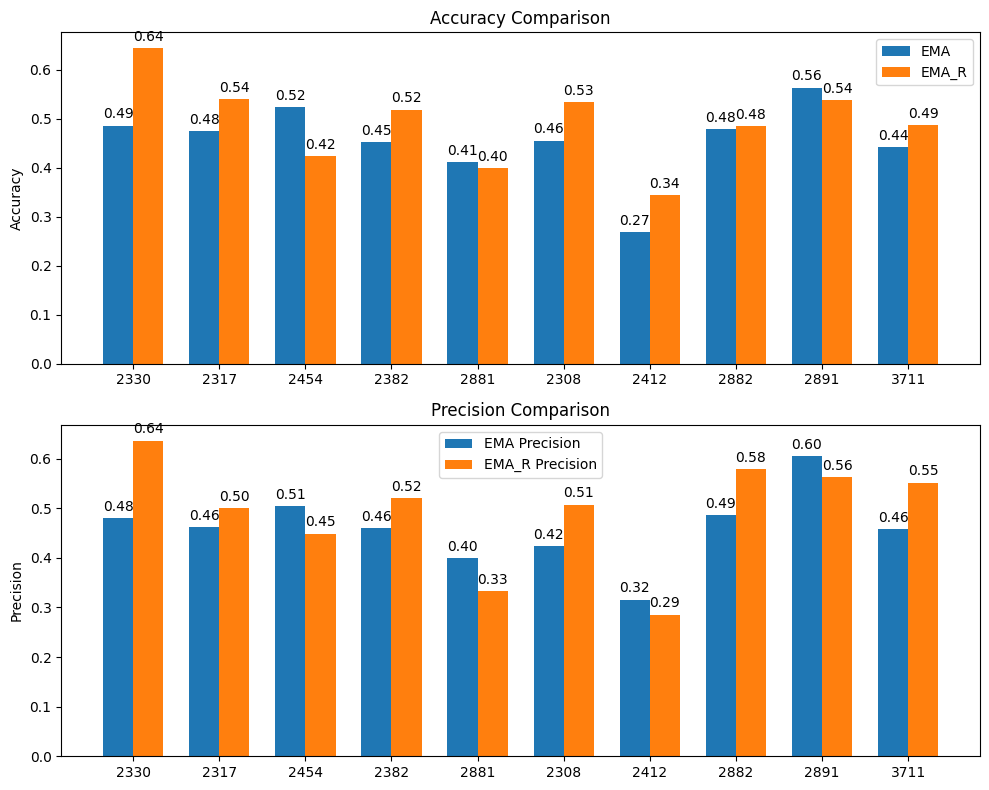

In [33]:
import json
import numpy as np
import matplotlib.pyplot as plt

# 記錄 accuracy 和 precision 的結果
accuracies_ema = []
precisions_ema = []
accuracies_ema_r = []
precisions_ema_r = []
avail_count = 0
ask_count = 0

for i in range(len(stock_ids)):
    print(f"stock id: {stock_ids[i]}, stock name: {stock_names[i]}")

    # 讀取 ema JSON 文件
    with open(path_out + stock_ids[i] + "ema_20230101_20240630.json", "r", encoding='utf-8') as f:
        data_ema = json.load(f)
        accuracies_ema.append(data_ema["result"]["accuracy"])
        precisions_ema.append(data_ema["result"]["precision"])
        print(data_ema["result"])
        avail_count += data_ema["result"]["avail_count"]
        ask_count += data_ema["result"]["ask_count"]

    # 讀取 ema_r JSON 文件
    with open(path_out + stock_ids[i] + "ema_r_20230101_20240630.json", "r", encoding='utf-8') as f:
        data_ema_r = json.load(f)
        accuracies_ema_r.append(data_ema_r["result"]["accuracy"])
        precisions_ema_r.append(data_ema_r["result"]["precision"])
        print(data_ema_r["result"])
        avail_count += data_ema_r["result"]["avail_count"]
        ask_count += data_ema_r["result"]["ask_count"]
print(f"ask_count:[{avail_count}/{ask_count}] (有效的回答(yes or no)/ 無法判斷的回答)")

# 開始繪圖
labels = stock_ids  # 股票名稱標籤
x = np.arange(len(labels))  # X 軸位置

# 設置長條圖的寬度
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# 畫出 accuracy 的長條圖
rects1 = ax1.bar(x - width/2, accuracies_ema, width, label='EMA')
rects2 = ax1.bar(x + width/2, accuracies_ema_r, width, label='EMA_R')

# 畫出 precision 的長條圖
rects3 = ax2.bar(x - width/2, precisions_ema, width, label='EMA Precision')
rects4 = ax2.bar(x + width/2, precisions_ema_r, width, label='EMA_R Precision')

# 設定圖表標題和軸標籤
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()

ax2.set_ylabel('Precision')
ax2.set_title('Precision Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()

# 顯示每個長條的值
def autolabel(rects, ax):
    """在每個長條圖上顯示其值"""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax1)
autolabel(rects2, ax1)
autolabel(rects3, ax2)
autolabel(rects4, ax2)

# 調整圖表佈局
fig.tight_layout()

# 顯示圖表
plt.show()


In [29]:
# with open(path_out + stock_ids[i] + "ema_20230101_20240630.json" , "r", encoding='utf-8') as f:
#     data = json.load(f)
# outdata = data["output_data"]

# # 印出outdata前一個日期的均線情況
# # 印出outdata前幾個元素
# for d in outdata:


#     # 讀取CSV檔案
#     datetime_d = datetime.strptime(d, '%Y%m%d')
#     last_d = (datetime_d - timedelta(days=1)).strftime('%Y%m%d')
#     df = pd.read_csv(path_price, encoding='utf-8')
#     df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')
#     df = df[(last_d == df['Date'])]
#     if df.empty:
#         continue
#     ema5 = "上漲" if df['EMA5'].values[0] > df["Close"].values[0] else "下跌"

#     print(d)
#     print(outdata[d]['raw_data'])
#     print(f"前一日的五日加權移動平均線為{ema5}趨勢")
#     print("_"*50)